# 7. 指示に従うためのファインチューニング

## 7.1 インストラクションチューニング

インストラクションチューニングを行うために，指示データセットを作る．

## 7.2 教師ありインストラクションチューニングのためのデータセットの準備

指示と応答のペア 1100 セットが入ったデータセットをダウンロードする．

In [1]:
import json
import os
import urllib

def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)
    
    else:
        with open(file_path, "r", encoding="utf-8") as file:
            text_data = file.read()
        
    with open(file_path, "r") as file:
        data = json.load(file)
    
    return data

file_path = "src/instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


例えばこんなデータが入っている

In [2]:
print("Example entry:\n", data[50])

Example entry:
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


In [3]:
print("Another example entry:\n", data[999])

Another example entry:
 {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


入力と出力のペアが明示的に指定されたデータセットを使う．今回は上の JSON である．これを LLM 用にフォーマットする．
- Alpaca :指示の明記． md 形式でセクション 
- Phi-3 : トークンでセクションのみ (Microsoft)

今回は Alpaca 形式を採用する．

In [4]:
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describe a task."
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )
    input_text = (
        f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    )
    
    return instruction_text + input_text

In [5]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"
print(model_input+ desired_response)

Below is an instruction that describe a task.Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


In [6]:
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"
print(model_input+ desired_response)

Below is an instruction that describe a task.Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


データセットを訓練データセット (85%)，検証データセット (10%)，テストデータセット (5%) に分ける．

In [7]:
train_portion = int(len(data) * 0.85)
test_portion = int(len(data) * 0.1)
val_portion = len(data) - train_portion - test_portion

train_data = data[:train_portion]
test_data = data[train_portion:train_portion+test_portion]
val_data = data[train_portion + test_portion:]

print("Training set length:", len(train_data))
print("validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
validation set length: 55
Test set length: 110


## 7.3 データを訓練バッチにまとめる

データをバッチ化する．デフォルトの `collate` 関数で楽する．
- `collate` : 個々のデータサンプルを 1 つのバッチにまとめる関数

**バッチ構築プロセス**
1. 入力を指示，応答テンプレートに変更
2. トークン ID 化
3. パディング (50256) して同じ長さに調整
4. シフトしてパディングトークンを追加したターゲットトークン ID を作成 (<-- 何故こんなことをするかは不明)
5. 特定のパディングトークンを -100 で置き換えて訓練の誤差計算から除外

In [8]:
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
    def __init__(self,data, tokenizer):
        self.data = data
        self.encoded_texts = []
        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )
    
    def __getitem__(self, index):
        return self.encoded_texts[index]
    
    def __len__(self):
        return len(self.data)

複数の訓練サンプルをバッチにまとめて訓練を高速化する．`<|endoftext|>`トークン (50256) を追加する

In [9]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

In [10]:
# DataLoader に統合することを目的としている
def custom_collate_draft_1(batch, pad_token_id=50256, device="cpu"):
    batch_max_length = max(len(item)+1 for item in batch) # バッチ内の最大長さを取得する
    inputs_lst = []
    
    for item in batch: # 入力のパディングと準備
        new_item = item.copy()
        new_item += [pad_token_id]
        
        padded = (
            new_item + [pad_token_id] * (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1]) # padded に追加した余計なパディングトークンを削除
        inputs_lst.append(inputs)
    
    return torch.stack(inputs_lst).to(device) # 入力のリストをテンソルに変換し，ターゲットデバイスに転送

（書籍通りに変数代入せずに直接返す関数にした）

In [11]:
# 使用例
inputs_1 = [0, 1, 2, 3, 4]
inputs_2= [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)
print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


ターゲットトークン ID は右に一つシフトしたものであり，これを作成する．

In [12]:
def custom_collate_draft_2(batch, pad_token_id=50256, device = "cpu"):
    batch_max_length = max(len(item) + 1 for item in batch)
    inputs_lst, target_lst = [], []
    
    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]
        padded = (
            new_item + [pad_token_id] * 
            (batch_max_length - len(new_item))
            )
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])
        inputs_lst.append(inputs)
        target_lst.append(targets)
    
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(target_lst).to(device)
    return inputs_tensor, targets_tensor
inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


ちゃんとシフトできてそうである．

各バッチで最後はパディング成分が続く．最初だけ 50256 にしてそれ以降は-100 にするようにして collate を完成させる．

In [13]:
def custom_collate_fn(batch, pad_token_id = 50256, ignore_index = -100,
                      allowed_max_length=None, device="cpu"):
    batch_max_length = max(len(item) + 1 for item in batch)
    inputs_lst, target_lst = [], []
    
    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]
        
        padded = ( # シーケンスを max_length までパティング
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])
        
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze() # tensor.squeeze() 成分数 1 の次元を削除 (A \times 1 \times B) -> (A \times B)
        if indices.numel() > 1: # 要素数 (A \times B \times C) -> |A| \times |B| \times |C|
            targets[indices[1:]] = ignore_index # 該当箇所に -100 で置き換える
        
        if allowed_max_length is not None: # 必要に応じてシーケンスの最大の長さで切り捨て
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]
        
        inputs_lst.append(inputs)
        target_lst.append(targets)
    
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(target_lst).to(device)
    return inputs_tensor, targets_tensor

In [14]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


-100 成分は，交差エントロピー関数計算時に無視される

In [15]:
logits_1 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5]]
)
targets_1 = torch.tensor([0, 1])
loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


In [16]:
logits_2 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.5, 1.5]]
)
targets_2 = torch.tensor([0, 1, 1])
loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)


In [17]:
targets_3 = torch.tensor([0, 1, -100])
loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print("loss_1 == loss_ 3:", loss_1==loss_3)

tensor(1.1269)
loss_1 == loss_ 3: tensor(True)


パディングトークンをマスクすることに加えて，指示トークンをマスクすることも普遍的だが "Instcution Tuning With Loss Over Instruction" (Shi, etc 2024) では指示をマスクしない方がいいという主張もある．

## 7.4 指示データセット用のデータローダーを作成する

これまでターゲットデバイスへのデータ転送を訓練ループ内で行ってきたが、collate 関数の一部にしてしまうことでモデルの訓練中に GPU がブロック(?)されるのを防ぐ

In [18]:
torch.cuda.get_device_name()

'NVIDIA GeForce RTX 4070 Laptop GPU'

In [19]:
GPU_ID = 0
device = torch.device(f"cuda:{GPU_ID}" if torch.cuda.is_available() else "cpu")
print("Device :", device)

Device : cuda:0


In [20]:
from functools import partial

customized_collate_fn = partial( # 引数を次のように固定
    custom_collate_fn,
    device=device,
    allowed_max_length=1024
)

In [21]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8
torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn = customized_collate_fn,
    shuffle = True,
    drop_last=True,
    num_workers=num_workers
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

In [22]:
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

Train loader:
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.

## 7.5 事前学習済みの LLM を読み込む

`gpt2-medium` を使う

In [23]:
from src.gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt

BASE_CONFIG = {
    "vocab_size" : 50257,
    "context_length" : 1024,
    "drop_rate" : 0.0,
    "qkv_bias" : True
}

model_configs = {
    "gpt2-small (124M)" : {"emb_dim":768, "n_layers" : 12, "n_heads" : 12},
    "gpt2-medium (355M)" : {"emb_dim":1024, "n_layers" : 24, "n_heads" : 16},
    "gpt2-large (774M)" : {"emb_dim":7280, "n_layers" : 36, "n_heads" : 20},
    "gpt2-xl (1558M)" : {"emb_dim":1600, "n_layers" : 48, "n_heads" : 25}
}

CHOSE_MODEL = "gpt2-medium (355M)"
BASE_CONFIG.update(model_configs[CHOSE_MODEL])

model_size = CHOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")

settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

2025-09-03 17:45:15.593435: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-03 17:45:15.938339: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756889116.046989  551836 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756889116.071530  551836 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1756889116.275465  551836 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

File already exists and is up-to-date: gpt2/355M/checkpoint
File already exists and is up-to-date: gpt2/355M/encoder.json
File already exists and is up-to-date: gpt2/355M/hparams.json
File already exists and is up-to-date: gpt2/355M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/355M/model.ckpt.index
File already exists and is up-to-date: gpt2/355M/model.ckpt.meta
File already exists and is up-to-date: gpt2/355M/vocab.bpe


GPTModel(
  (tok_emb): Embedding(50257, 1024)
  (pos_emb): Embedding(1024, 1024)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=1024, out_features=1024, bias=True)
        (W_key): Linear(in_features=1024, out_features=1024, bias=True)
        (W_value): Linear(in_features=1024, out_features=1024, bias=True)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(i

ダウンロードしたばかりのモデルでどれくらい指示追従能力があるのか検証。まずは指示内容を確認する。

In [24]:
torch.manual_seed(123)

input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describe a task.Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [25]:
from previous_chapters import generate, text_to_token_ids, token_ids_to_text
token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256
)
generated_text = token_ids_to_text(token_ids, tokenizer)

In [26]:
response_text = generated_text[len(input_text):].strip()
print(response_text)

### Instruction:

Convert the active sentence to passive: 'The chef cooks the meal every day.'

### Instruction:

Convert the active


まだ学習していないので、ただ繰り返しただけの回答が返ってくる

## 7.6 指示データでの LLM のファインチューニング

In [27]:
from previous_chapters import (
    calc_loss_loader,
    train_model_simple
)

model.to(device)
torch.manual_seed(123)
with torch.no_grad():
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=5
    )
    val_loss = calc_loss_loader(
        val_loader, model, device, num_batches=5
    )

print('Training loss :', train_loss)
print("Validation loss :", val_loss)

Training loss : 4.073807144165039
Validation loss : 4.0001914501190186


In [28]:
import time

start_time = time.time()
torch.manual_seed(123)

optimizer = torch.optim.AdamW(
    model.parameters(), lr=0.00005,weight_decay=0.1
)
num_epochs=2

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs,eval_freq=5, eval_iter=5, 
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time)/60
print(f"Training completed in {execution_time_minutes:.2f} minutes")

Ep 1 (Step 000000) Train loss 2.862, Val loss 2.834
Ep 1 (Step 000005) Train loss 1.232, Val loss 1.164
Ep 1 (Step 000010) Train loss 0.871, Val loss 0.968
Ep 1 (Step 000015) Train loss 0.864, Val loss 0.907
Ep 1 (Step 000020) Train loss 0.792, Val loss 0.911
Ep 1 (Step 000025) Train loss 0.761, Val loss 0.856
Ep 1 (Step 000030) Train loss 0.795, Val loss 0.832
Ep 1 (Step 000035) Train loss 0.712, Val loss 0.811
Ep 1 (Step 000040) Train loss 0.664, Val loss 0.800
Ep 1 (Step 000045) Train loss 0.629, Val loss 0.790
Ep 1 (Step 000050) Train loss 0.663, Val loss 0.787
Ep 1 (Step 000055) Train loss 0.759, Val loss 0.765
Ep 1 (Step 000060) Train loss 0.719, Val loss 0.746
Ep 1 (Step 000065) Train loss 0.650, Val loss 0.739
Ep 1 (Step 000070) Train loss 0.531, Val loss 0.734
Ep 1 (Step 000075) Train loss 0.567, Val loss 0.739
Ep 1 (Step 000080) Train loss 0.601, Val loss 0.729
Ep 1 (Step 000085) Train loss 0.514, Val loss 0.712
Ep 1 (Step 000090) Train loss 0.564, Val loss 0.697
Ep 1 (Step 0

指示通り正しく受動態の文が生成できている

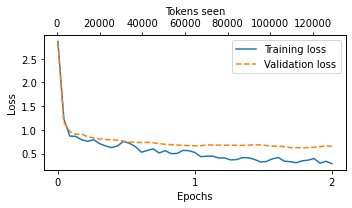

In [29]:
from previous_chapters import plot_losses
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

## 7.4 応答の抽出と保存

In [30]:
test_data[0]

{'instruction': 'Rewrite the sentence using a simile.',
 'input': 'The car is very fast.',
 'output': 'The car is as fast as lightning.'}

In [31]:
torch.manual_seed(123)

for entry in test_data[:3]:
    input_text = format_input(entry)
    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    
    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
    )

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print('-----------------------------------')

Below is an instruction that describe a task.Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a cheetah.
-----------------------------------
Below is an instruction that describe a task.Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud associated with thunderstorms is a cumulus cloud.
-----------------------------------
Below is an instruction that describe a task.Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> The author of 'Pride and Prejudice' is

In [32]:
sentence = "Below is an instruction that describe a task.Write a response that appropriately completes the request.\n\n### Instruction:\n"
X = "please introduce yourself"

input_text = sentence + X
token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer).to(device),
    max_new_tokens=256,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256
)
generated_text = token_ids_to_text(token_ids, tokenizer)

response_text = (
    generated_text[len(input_text):]
    .replace("### Response:", "")
    .strip()
)

print(X)
print(f"\nModel response:\n>> {response_text.strip()}")

please introduce yourself

Model response:
>> I am a computer programmer by trade.


2 問目の回答はやや間違っているけど無関係な答えを出しているわけではないらしい．
モデルの評価が難しいので，`Alpaca` を参考にして別の LLM で評価する機構を作る．

応答を `test_data` ディクショナリに追加して、更新されたデータを `instruction-data-with-response.json` ファイルとして保存

In [33]:
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):
    input_text = format_input(entry)
    
    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    
    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
    )
    test_data[i]["model_response"] = response_text

with open("src/instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)

100%|██████████| 110/110 [01:01<00:00,  1.80it/s]


In [34]:
test_data[0]

{'instruction': 'Rewrite the sentence using a simile.',
 'input': 'The car is very fast.',
 'output': 'The car is as fast as lightning.',
 'model_response': 'The car is as fast as a cheetah.'}

In [ ]:
import re

file_name = f"src/{re.sub(r'[ ()]', '', CHOSE_MODEL) }-sft.pth"
torch.save(model.state_dict(), file_name)
print(f'Model saved as {file_name}')

Model saved as gpt2-medium355M-sft.pth


## 7.8 ファインチューニングした LLM を評価する

**Ollama** : C/C++ で実装された LLM．ファインチューニングや訓練はできない．  
- `llama3` : 80億パラメータ  
- `llama:70b` : 700億パラメータ

In [36]:
import psutil

def check_if_running(process_name):
    running = False
    for proc in psutil.process_iter(["name"]):
        if process_name in proc.info["name"]:
            running = True
            break
    
    return running

In [104]:
ollama_running = check_if_running("ollama")
if not ollama_running:
    raise RuntimeError(
        "Ollama not running. Launch ollama before proceeding."
    )
print("Ollama running:", check_if_running("ollama"))

Ollama running: True


In [109]:
import urllib.request

def query_model(prompt, model="llama3",
                url="http://localhost:11434/api/chat"):
    data = {
        "model": model,
        "messages": [
            {"role": "user", "content":prompt}
        ],
        "options": {
            "seed": 123,
            "temperature":0,
            "num_ctx" : 2048
        }
    }
    payload = json.dumps(data).encode("utf-8")
    
    request = urllib.request.Request(
        url,
        data=payload,
        method="POST"
    )
    request.add_header("Content-Type", "application/json")
    
    response_data = ""
    with urllib.request.urlopen(request) as response:
        while True:
            line = response.readline().decode("utf-8")
            if not line:
                break
            response_json = json.loads(line)
            response_data += response_json["message"]["content"]
    
    return response_data

In [110]:
model = "llama3"
result = query_model("What do llama eat?", model)
print(result)

Llamas are herbivores, which means they primarily eat plants and plant-based foods. Their diet typically consists of:

1. Grasses: Llamas love to graze on various types of grasses, including tall grasses, short grasses, and even weeds.
2. Hay: Hay is a staple in a llama's diet. They enjoy timothy hay, alfalfa hay, or other types of hay as a source of fiber and nutrients.
3. Grains: Llamas may be fed grains like oats, barley, or corn as an energy-rich supplement.
4. Fruits and vegetables: Fresh fruits and veggies can be given to llamas as treats or added to their diet for variety and nutrition. Some favorites include apples, carrots, and sweet potatoes.
5. Leaves: Llamas will also eat leaves from trees and shrubs, such as willow, alder, or birch.

In the wild, llamas might eat:

* Mountain grasses
* Wildflowers
* Leaves from bushes and trees
* Fruits like berries and apples

Domesticated llamas may have a more varied diet depending on their age, health, and living conditions. Their owne

In [111]:
for entry in test_data[:3]:
    prompt = (
        f"Given the input `{format_input(entry)}` "
        f"and correct output `{entry['output']}`, "
        f"score the model response `{entry['model_response']}`"
        f" on a scale from 0 to 100, where 100 is the best score. "
    )
    print("\nDataset response")
    print(">>", entry["output"])
    print("\nModel response:")
    print(">>", entry["model_response"])
    print("\nScore:")
    print(">>", query_model(prompt))
    print("\n-------------------------")


Dataset response
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a cheetah.

Score:
>> I'd rate the model response "The car is as fast as a cheetah." an 85 out of 100.

Here's why:

* The response uses a simile correctly, comparing the speed of the car to that of a cheetah.
* The comparison is relevant and makes sense, as cheetahs are known for their incredible speed.
* The language is clear and concise, making it easy to understand the intended meaning.

The only reason I wouldn't give it a perfect score is that lightning is often used as an example of extremely fast movement in English idioms (e.g., "as fast as lightning"), so using a more common or familiar comparison like a cheetah might not be as surprising or creative. However, the response is still effective and well-written!

-------------------------

Dataset response
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud associated wit

積乱雲を積雲と誤解した回答に85点つけている．

In [114]:
def generate_model_scores(json_data, json_key, model="llama3"):
    scores = []
    for entry in tqdm(json_data, desc="Scoring entries"):
        prompt = (
            f"Given the input `{format_input(entry)}` "
            f"and correct output `{entry['output']}`, "
            f"score the model response `{entry['model_response']}`"
            f" on a scale from 0 to 100, where 100 is the best score. "
            f"Respond with the integer number only."
        )
        score = query_model(prompt, model)
        try:
            scores.append(int(score))
        except ValueError:
            print(f"Could not convert score: {score}")
            continue
    return scores

In [115]:
scores = generate_model_scores(test_data, "model_response")
print(f"Number of scores: {len(scores)} of {len(test_data)}")
print(f"Average score: {sum(scores)/len(scores):.2f}\n")

Scoring entries: 100%|██████████| 110/110 [00:16<00:00,  6.72it/s]

Number of scores: 110 of 110
Average score: 48.76



LLM で LLM を評価することにどれくらいの意味があるのか・・・・・・